Saved: /Users/nandan/Desktop/CTCs/IBM/ns4_bootstrap_overlay.png
Saved: /Users/nandan/Desktop/CTCs/IBM/ns4_bootstrap_overlay.pdf


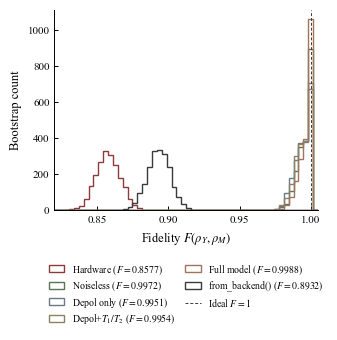

In [1]:
"""
Figure NS4: Bootstrap F distributions — hardware vs noise models
Single-column (~3.4 in), Times serif, stepped outlines, paper palette.
"""
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------------- Data ----------------
with open("noisy_sim_validation_results.json") as f:
    d = json.load(f)

# Hardware bootstrap is not in the file -> draw a normal sample from F+/-CI
# Actually: the JSON has F, F_lo, F_hi for hardware but no bootstrap array.
# We'll approximate the hardware distribution by a normal centered at F with
# std = (F_hi - F_lo) / (2 * 1.96), drawn at 2000 samples to match the sims.
hw_F   = d["hardware"]["F"]
hw_lo  = d["hardware"]["F_lo"]
hw_hi  = d["hardware"]["F_hi"]
hw_std = (hw_hi - hw_lo) / (2 * 1.96)
rng = np.random.default_rng(0)
hw_boot = rng.normal(hw_F, hw_std, size=2000)

series = [
    ("Hardware",         hw_boot,                                   hw_F),
    ("Noiseless",        np.array(d["sim_results"]["NM0_noiseless"]["bootstrap_F"]),
                                                                    d["sim_results"]["NM0_noiseless"]["F"]),
    ("Depol only",       np.array(d["sim_results"]["NM1_depol"]["bootstrap_F"]),
                                                                    d["sim_results"]["NM1_depol"]["F"]),
    (r"Depol+$T_1/T_2$", np.array(d["sim_results"]["NM2_thermal"]["bootstrap_F"]),
                                                                    d["sim_results"]["NM2_thermal"]["F"]),
    ("Full model",       np.array(d["sim_results"]["NM3_full"]["bootstrap_F"]),
                                                                    d["sim_results"]["NM3_full"]["F"]),
    ("from_backend()",   np.array(d["sim_results"]["NM4_auto"]["bootstrap_F"]),
                                                                    d["sim_results"]["NM4_auto"]["F"]),
]

# ---------------- PRL rcParams ----------------
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":    "stix",
    "font.size":           8,
    "axes.labelsize":      9,
    "xtick.labelsize":     8,
    "ytick.labelsize":     8,
    "legend.fontsize":     7.0,
    "axes.linewidth":      0.7,
    "xtick.major.width":   0.7,
    "ytick.major.width":   0.7,
    "xtick.major.size":    3.0,
    "ytick.major.size":    3.0,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.top":           False,
    "ytick.right":         False,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "savefig.bbox":        "tight",
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
})

# Paper palette
C_PS    = "#5b7553"   # sage
C_DYN   = "#8c3b3b"   # brick
C_GREY  = "#3a3a3a"
C_SLATE = "#6b7a85"
C_KHAKI = "#8a8160"
C_WARM  = "#a0735d"

colors  = [C_DYN, C_PS, C_SLATE, C_KHAKI, C_WARM, C_GREY]

# ---------------- Figure ----------------
fig, ax = plt.subplots(figsize=(3.4, 2.6))

bins = np.linspace(0.82, 1.005, 55)

for (label, samples, F_mean), col in zip(series, colors):
    ax.hist(samples, bins=bins,
            histtype="step", linewidth=1.0, color=col,
            label=f"{label} ($F = {F_mean:.4f}$)")

ax.axvline(1.0, color=C_GREY, lw=0.7, linestyle=(0,(3,2)),
           label=r"Ideal $F = 1$")

ax.set_xlabel(r"Fidelity $F(\rho_Y,\rho_M)$")
ax.set_ylabel("Bootstrap count")
ax.set_xlim(0.82, 1.005)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22),
          frameon=False, handlelength=1.6, ncol=2,
          columnspacing=1.0, labelspacing=0.30)

# Save
out_png = "/Users/nandan/Desktop/CTCs/IBM/ns4_bootstrap_overlay.png"
out_pdf = "/Users/nandan/Desktop/CTCs/IBM/ns4_bootstrap_overlay.pdf"
plt.savefig(out_png, dpi=600)
plt.savefig(out_pdf)
print("Saved:", out_png)
print("Saved:", out_pdf)